In [1]:
import os
os.getcwd()

from pathlib import Path
Path("build/pdd_dose.txt").exists()

True

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            ix = int(parts[0]); iy = int(parts[1]); iz = int(parts[2])
            val = float(parts[3]); val2 = float(parts[4]); entry = int(float(parts[5]))
            rows.append((ix, iy, iz, val, val2, entry))
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val","val2","entry"])

=== NO SHIFT ===
MAE = 0.011586764796372476 RMSE = 0.013277002266656382 MaxAbs = 0.021285379954258735

=== BEST SHIFT (by MAE) ===
best_shift = 0.0 mm
   shift_mm       MAE      RMSE    MaxAbs
0      0.00  0.011587  0.013277  0.021285
1      0.25  0.011876  0.014042  0.022717
2     -0.25  0.013000  0.015333  0.030961
3      0.50  0.014982  0.016783  0.026779
4     -0.50  0.015119  0.019064  0.043616
5     -0.75  0.017239  0.023655  0.056270
6      0.75  0.019133  0.020792  0.031113
7     -1.00  0.019272  0.028763  0.067382
8     -1.25  0.022326  0.034213  0.078493
9      1.00  0.023540  0.025917  0.037129

=== WITH BEST SHIFT ===
MAE = 0.011586764796372476 RMSE = 0.013277002266656382 MaxAbs = 0.021285379954258735


,depth_mm,meas_pdd,sim_noShift,diff_noShift,pct_noShift_%,sim_bestShift,diff_bestShift,pct_bestShift_%
0,5.0,0.9847,0.966068,-0.018632,-1.892157,0.966068,-0.018632,-1.892157
1,10.0,0.9985,0.986010,-0.012490,-1.250862,0.986010,-0.012490,-1.250862
2,15.0,1.0000,0.997668,-0.002332,-0.233175,0.997668,-0.002332,-0.233175
3,20.0,0.9832,0.994168,0.010968,1.115551,0.994168,0.010968,1.115551
4,25.0,0.9358,0.951126,0.015326,1.637762,0.951126,0.015326,1.637762
5,30.0,0.8394,0.844180,0.004780,0.569441,0.844180,0.004780,0.569441
6,35.0,0.6713,0.662009,-0.009291,-1.384012,0.662009,-0.009291,-1.384012
7,40.0,0.4480,0.429386,-0.018614,-4.155013,0.429386,-0.018614,-4.155013
8,45.0,0.2187,0.214402,-0.004298,-1.965387,0.214402,-0.004298,-1.965387
9,50.0,0.0596,0.077301,0.017701,29.698987,0.077301,0.017701,29.698987


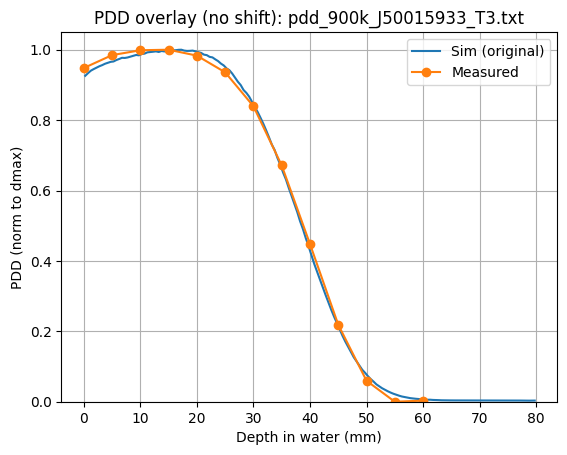

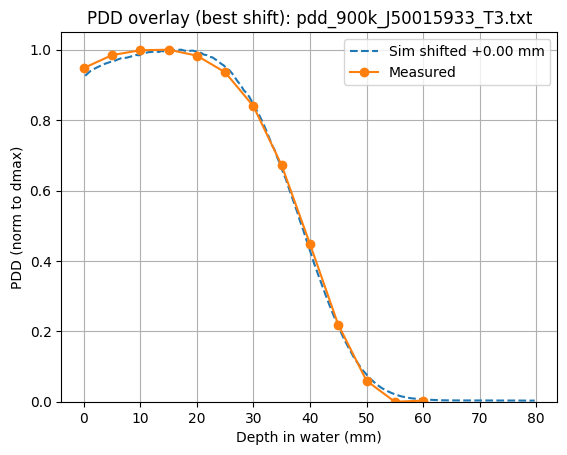

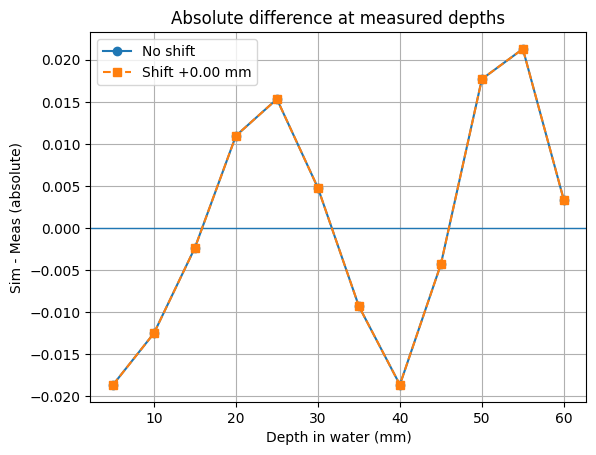

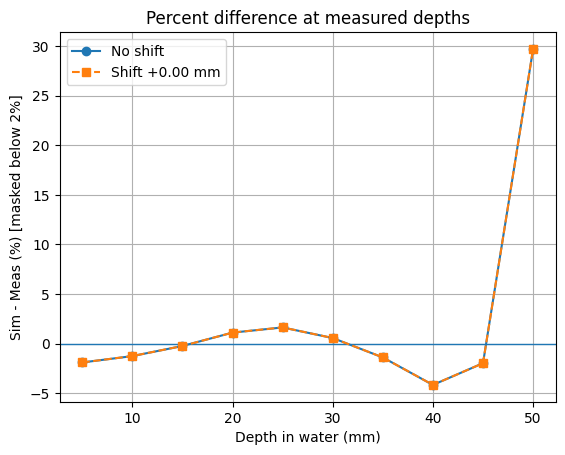

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# USER SETTINGS
# =========================
PDD_TXT = Path("build") / "pdd_900k_J50015933_T3.txt"   # <-- change
#build/pdd_900k_J50015933_T3.txt
#build/pdd_100k_J50015885_T1.txt
NBIN_Z = 160
HALF_Z_MM = 40
DEPTH_MODE = "center"   # use "center" for voxel centers

# =========================
# Measured PDD (Conv 9)
# =========================
# Depth (mm), NormC (% of dmax)
meas_depth = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60], dtype=float)
meas_normC = np.array([94.80,98.47,99.85,100.00,98.32,93.58,83.94,67.13,44.80,21.87,5.96,0.00,0.31], dtype=float)

# Convert to 0..1
meas_pdd = meas_normC / 100.0

# =========================
# Read Geant4 mesh dump
# =========================
def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            try:
                ix = int(parts[0]); iy = int(parts[1]); iz = int(parts[2])
                val = float(parts[3])     # dose (Gy) or energy deposit
                rows.append((ix, iy, iz, val))
            except ValueError:
                continue
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val"])



df = read_geant4_mesh_dump(PDD_TXT)

g = df.groupby("iZ", as_index=False)["val"].sum()
all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

dose = g["val"].to_numpy()
if dose.max() <= 0:
    raise RuntimeError("Dose is zero everywhere — check mesh placement and beamOn.")

# Depth axis from mesh settings
full_len = 2.0 * HALF_Z_MM
dz = full_len / NBIN_Z
if DEPTH_MODE == "center":
    sim_depth = (np.arange(NBIN_Z) + 0.5) * dz
else:
    sim_depth = np.arange(NBIN_Z) * dz

sim_pdd = dose / dose.max()

# =========================
# Comparison utilities
# =========================
def compute_metrics(sim_at_meas, meas):
    diff = sim_at_meas - meas
    mae  = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    maxabs = float(np.max(np.abs(diff)))
    return diff, mae, rmse, maxabs

def safe_pct_diff(sim_at_meas, meas, eps=0.02):
    """
    Percent diff = 100*(sim-meas)/meas, but only where meas >= eps (default 0.02 = 2%).
    Returns array with NaN where meas is too small.
    """
    pct = np.full_like(meas, np.nan, dtype=float)
    m = meas >= eps
    pct[m] = 100.0 * (sim_at_meas[m] - meas[m]) / meas[m]
    return pct

# =========================
# 1) Metrics WITHOUT shift
# =========================
sim0 = np.interp(meas_depth_use, sim_depth, sim_pdd)
diff0, mae0, rmse0, maxabs0 = compute_metrics(sim0, meas_pdd_use)
pct0 = safe_pct_diff(sim0, meas_pdd_use, eps=0.02)

print("=== NO SHIFT ===")
print("MAE =", mae0, "RMSE =", rmse0, "MaxAbs =", maxabs0)

# =========================
# 2) Find best depth shift (mm) by minimizing MAE
# =========================
shifts = np.arange(-3.0, 3.01, 0.25)   # tune range/step if you want
rows = []
for s in shifts:
    sim_s = np.interp(meas_depth_use, sim_depth + s, sim_pdd, left=np.nan, right=np.nan)
    m = np.isfinite(sim_s)
    if not np.any(m):
        continue
    diff = sim_s[m] - meas_pdd_use[m]
    mae  = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    maxabs = float(np.max(np.abs(diff)))
    rows.append((s, mae, rmse, maxabs))

shift_df = pd.DataFrame(rows, columns=["shift_mm","MAE","RMSE","MaxAbs"]).sort_values("MAE").reset_index(drop=True)

best_shift = float(shift_df.loc[0, "shift_mm"])
print("\n=== BEST SHIFT (by MAE) ===")
print("best_shift =", best_shift, "mm")
print(shift_df.head(10))

# =========================
# 3) Metrics WITH best shift
# =========================
sim_best = np.interp(meas_depth_use, sim_depth + best_shift, sim_pdd)
diffB, maeB, rmseB, maxabsB = compute_metrics(sim_best, meas_pdd_use)
pctB = safe_pct_diff(sim_best, meas_pdd_use, eps=0.02)

print("\n=== WITH BEST SHIFT ===")
print("MAE =", maeB, "RMSE =", rmseB, "MaxAbs =", maxabsB)

# =========================
# 4) Publishable tables
# =========================
out = pd.DataFrame({
    "depth_mm": meas_depth_use,
    "meas_pdd": meas_pdd_use,
    "sim_noShift": sim0,
    "diff_noShift": diff0,
    "pct_noShift_%": pct0,
    "sim_bestShift": sim_best,
    "diff_bestShift": diffB,
    "pct_bestShift_%": pctB
})
display(out)

# =========================
# 5) Plots
# =========================
# (A) Overlay: original
plt.figure()
plt.plot(sim_depth, sim_pdd, label="Sim (original)")
plt.plot(meas_depth, meas_pdd, "o-", label="Measured")
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (norm to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.title(f"PDD overlay (no shift): {PDD_TXT.name}")
plt.show()

# (B) Overlay: shifted
plt.figure()
plt.plot(sim_depth + best_shift, sim_pdd, "--", label=f"Sim shifted {best_shift:+.2f} mm")
plt.plot(meas_depth, meas_pdd, "o-", label="Measured")
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (norm to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.title(f"PDD overlay (best shift): {PDD_TXT.name}")
plt.show()

# (C) Absolute differences at meas depths
plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(meas_depth_use, diff0, "o-", label="No shift")
plt.plot(meas_depth_use, diffB, "s--", label=f"Shift {best_shift:+.2f} mm")
plt.xlabel("Depth in water (mm)")
plt.ylabel("Sim - Meas (absolute)")
plt.grid(True)
plt.legend()
plt.title("Absolute difference at measured depths")
plt.show()

# (D) Percent differences (masked where meas < 2%)
plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(meas_depth_use, pct0, "o-", label="No shift")
plt.plot(meas_depth_use, pctB, "s--", label=f"Shift {best_shift:+.2f} mm")
plt.xlabel("Depth in water (mm)")
plt.ylabel("Sim - Meas (%) [masked below 2%]")
plt.grid(True)
plt.legend()
plt.title("Percent difference at measured depths")
plt.show()


================= PDD COMPARISON (NO SHIFT) =================
File: build/pdd_900k_J50015933_T3.txt
dz = 0.500 mm (NBIN_Z=160, HALF_Z_MM=40.0, mode=center)
MAE      = 0.01159  (target <= 0.020)
RMSE     = 0.01328
MaxAbs   = 0.02129
MaxAbs (meas>=2%) = 0.01863  (target <= 0.050)
Tail MAE (depth>=35 mm) = 0.01242  (target <= 0.030)
--------------------------------------------------------------
ACCEPTANCE (example criteria):
  MAE_OK      : True
  MaxAbs_OK   : True
  Tail_OK     : True

OVERALL: ACCEPTABLE FIT



,depth_mm,meas_pdd,sim_pdd_interp,diff,abs_diff,pct_diff_% (masked<2%)
0,5.0,0.9847,0.966068,-0.018632,0.018632,-1.892157
1,10.0,0.9985,0.986010,-0.012490,0.012490,-1.250862
2,15.0,1.0000,0.997668,-0.002332,0.002332,-0.233175
3,20.0,0.9832,0.994168,0.010968,0.010968,1.115551
4,25.0,0.9358,0.951126,0.015326,0.015326,1.637762
5,30.0,0.8394,0.844180,0.004780,0.004780,0.569441
6,35.0,0.6713,0.662009,-0.009291,0.009291,-1.384012
7,40.0,0.4480,0.429386,-0.018614,0.018614,-4.155013
8,45.0,0.2187,0.214402,-0.004298,0.004298,-1.965387
9,50.0,0.0596,0.077301,0.017701,0.017701,29.698987


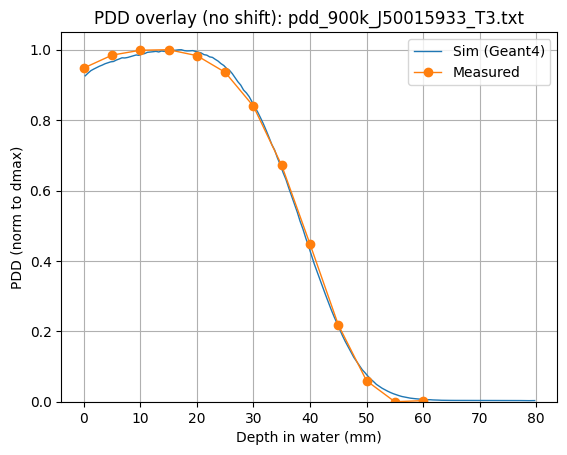

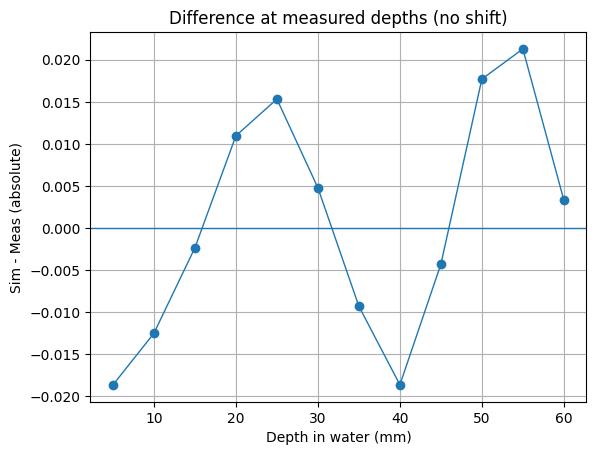

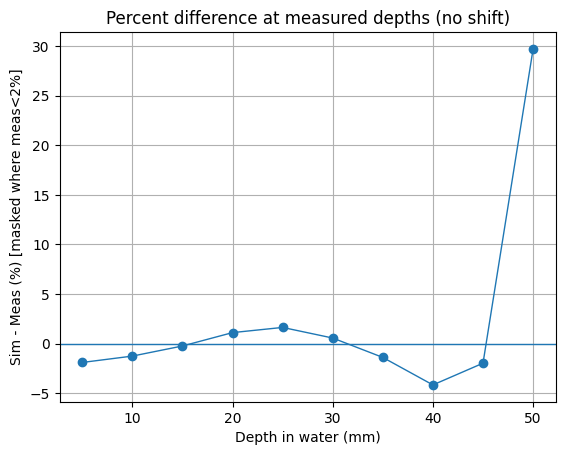

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# USER SETTINGS
# =========================
PDD_TXT = Path("build") / "pdd_900k_J50015933_T3.txt"   # <-- change
NBIN_Z = 160
HALF_Z_MM = 40.0
DEPTH_MODE = "center"   # "center" for voxel centers

# =========================
# Measured PDD (Conv 9)  (normalized to dmax=1)
# =========================
meas_depth = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60], dtype=float)
meas_normC = np.array([94.80,98.47,99.85,100.00,98.32,93.58,83.94,67.13,44.80,21.87,5.96,0.00,0.31], dtype=float)
meas_pdd   = meas_normC / 100.0

# =========================
# Helper: read Geant4 mesh dump
# =========================
def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            try:
                ix = int(parts[0]); iy = int(parts[1]); iz = int(parts[2])
                val = float(parts[3])
                rows.append((ix, iy, iz, val))
            except ValueError:
                continue
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val"])

# =========================
# Build simulated PDD curve
# =========================
df = read_geant4_mesh_dump(PDD_TXT)

# sum over iX,iY per iZ (even if you later use >1 bin in XY)
g = df.groupby("iZ", as_index=False)["val"].sum()
all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

dose = g["val"].to_numpy()
if dose.max() <= 0:
    raise RuntimeError("Dose is zero everywhere — check beamOn, mesh placement, and scoring.")

sim_pdd = dose / dose.max()

# depth axis
full_len = 2.0 * HALF_Z_MM
dz = full_len / NBIN_Z
if DEPTH_MODE == "center":
    sim_depth = (np.arange(NBIN_Z) + 0.5) * dz
else:
    sim_depth = np.arange(NBIN_Z) * dz

# =========================
# Compare at measurement depths (NO SHIFT)
# =========================
mask = (meas_depth >= sim_depth.min()) & (meas_depth <= sim_depth.max())
meas_depth_use = meas_depth[mask]
meas_pdd_use   = meas_pdd[mask]

sim_at_meas = np.interp(meas_depth_use, sim_depth, sim_pdd)

diff = sim_at_meas - meas_pdd_use
absdiff = np.abs(diff)

MAE  = float(np.mean(absdiff))
RMSE = float(np.sqrt(np.mean(diff**2)))
MaxAbs = float(np.max(absdiff))

# Percent diff only where measured >= 2% (avoid nonsense near ~0)
eps = 0.02
pct = np.full_like(meas_pdd_use, np.nan, dtype=float)
m = meas_pdd_use >= eps
pct[m] = 100.0 * diff[m] / meas_pdd_use[m]

# =========================
# Acceptance rules (edit if your group uses something else)
# =========================
# Typical "good" for a Monte Carlo beam model in water:
# - MAE <= 0.02 (2% in normalized PDD)
# - MaxAbs <= 0.05 (5%) for depths where meas >= 2%
# - Tail region often judged separately (e.g. depth >= 35 mm)
MAE_OK = (MAE <= 0.02)

# MaxAbs in region where measured >= 2%
MaxAbs_nonzero = float(np.nanmax(absdiff[m])) if np.any(m) else float("nan")
MaxAbs_OK = (MaxAbs_nonzero <= 0.05) if np.isfinite(MaxAbs_nonzero) else False

# Tail check (example: >=35 mm)
tail_mask = meas_depth_use >= 35.0
tail_mae = float(np.mean(np.abs(diff[tail_mask]))) if np.any(tail_mask) else np.nan
TAIL_OK = (tail_mae <= 0.03) if np.isfinite(tail_mae) else False  # 3% MAE in tail

print("\n================= PDD COMPARISON (NO SHIFT) =================")
print(f"File: {PDD_TXT}")
print(f"dz = {dz:.3f} mm (NBIN_Z={NBIN_Z}, HALF_Z_MM={HALF_Z_MM}, mode={DEPTH_MODE})")
print(f"MAE      = {MAE:.5f}  (target <= 0.020)")
print(f"RMSE     = {RMSE:.5f}")
print(f"MaxAbs   = {MaxAbs:.5f}")
print(f"MaxAbs (meas>=2%) = {MaxAbs_nonzero:.5f}  (target <= 0.050)")
print(f"Tail MAE (depth>=35 mm) = {tail_mae:.5f}  (target <= 0.030)")
print("--------------------------------------------------------------")
print("ACCEPTANCE (example criteria):")
print(f"  MAE_OK      : {MAE_OK}")
print(f"  MaxAbs_OK   : {MaxAbs_OK}")
print(f"  Tail_OK     : {TAIL_OK}")
ACCEPT = bool(MAE_OK and MaxAbs_OK and TAIL_OK)
print(f"\nOVERALL: {'ACCEPTABLE FIT' if ACCEPT else 'NOT YET ACCEPTABLE'}")
print("==============================================================\n")

# =========================
# Table + plots
# =========================
out = pd.DataFrame({
    "depth_mm": meas_depth_use,
    "meas_pdd": meas_pdd_use,
    "sim_pdd_interp": sim_at_meas,
    "diff": diff,
    "abs_diff": absdiff,
    "pct_diff_% (masked<2%)": pct
})
display(out)

# Overlay
plt.figure()
plt.plot(sim_depth, sim_pdd, label="Sim (Geant4)", linewidth=1)
plt.plot(meas_depth, meas_pdd, "o-", label="Measured", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (norm to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.title(f"PDD overlay (no shift): {PDD_TXT.name}")
plt.show()

# Abs diff at measurement points
plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(meas_depth_use, diff, "o-", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("Sim - Meas (absolute)")
plt.grid(True)
plt.title("Difference at measured depths (no shift)")
plt.show()

# Percent diff (masked)
plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(meas_depth_use, pct, "o-", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("Sim - Meas (%) [masked where meas<2%]")
plt.grid(True)
plt.title("Percent difference at measured depths (no shift)")
plt.show()

Using best_shift = 1.5
MAE = 0.03196955663229834 RMSE = 0.03649450905281992 MaxAbs = 0.053723955089873265


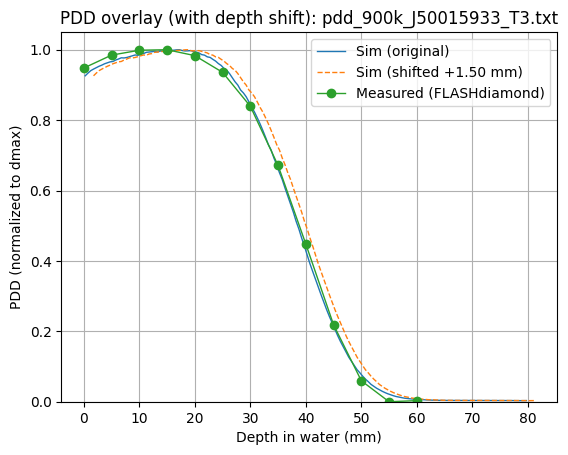

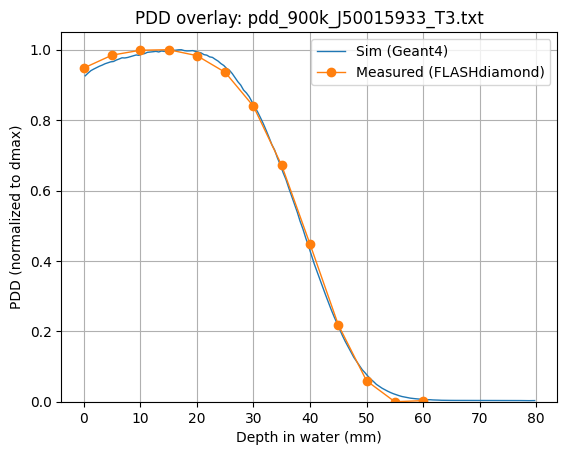

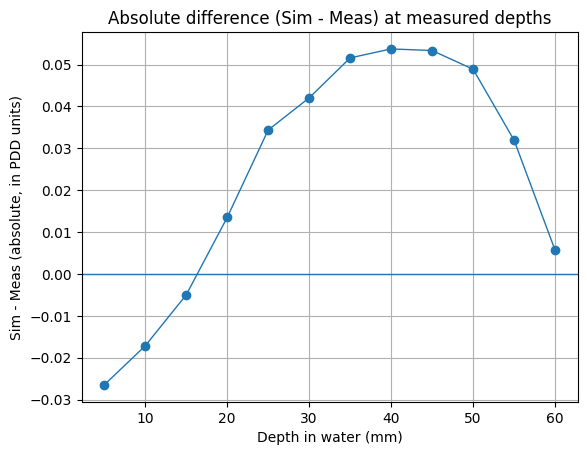

NameError: name 'pct_diff' is not defined

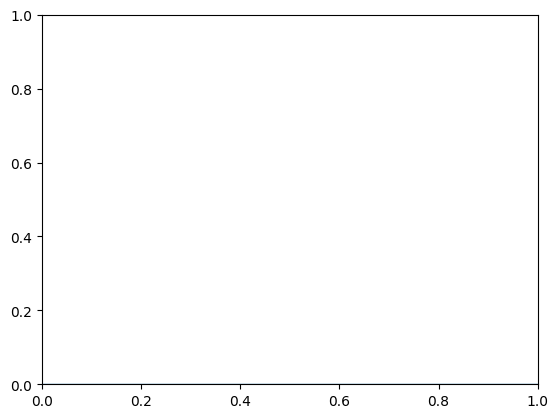

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# USER SETTINGS
# =========================
PDD_TXT = Path("build") / "pdd_900k_J50015933_T3.txt"   # <-- change
#build/pdd_900k_J50015933_T3.txt
#build/pdd_100k_J50015885_T1.txt
NBIN_Z = 160
HALF_Z_MM = 40
DEPTH_MODE = "center"   # use "center" for voxel centers

# =========================
# Measured PDD (Conv 9)
# =========================
# Depth (mm), NormC (% of dmax)
meas_depth = np.array([0,5,10,15,20,25,30,35,40,45,50,55,60], dtype=float)
meas_normC = np.array([94.80,98.47,99.85,100.00,98.32,93.58,83.94,67.13,44.80,21.87,5.96,0.00,0.31], dtype=float)

# Convert to 0..1
meas_pdd = meas_normC / 100.0

# =========================
# Read Geant4 mesh dump
# =========================
def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            try:
                ix = int(parts[0]); iy = int(parts[1]); iz = int(parts[2])
                val = float(parts[3])     # dose (Gy) or energy deposit
                rows.append((ix, iy, iz, val))
            except ValueError:
                continue
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val"])



df = read_geant4_mesh_dump(PDD_TXT)

g = df.groupby("iZ", as_index=False)["val"].sum()
all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

dose = g["val"].to_numpy()
if dose.max() <= 0:
    raise RuntimeError("Dose is zero everywhere — check mesh placement and beamOn.")

# Depth axis from mesh settings
full_len = 2.0 * HALF_Z_MM
dz = full_len / NBIN_Z
if DEPTH_MODE == "center":
    sim_depth = (np.arange(NBIN_Z) + 0.5) * dz
else:
    sim_depth = np.arange(NBIN_Z) * dz

sim_pdd = dose / dose.max()

# =========================
# Interpolate sim PDD onto measured depths (0..60 mm)
# =========================
# Limit interpolation to sim depth range
mask = (meas_depth >= sim_depth.min()) & (meas_depth <= sim_depth.max())
meas_depth_use = meas_depth[mask]
meas_pdd_use = meas_pdd[mask]

#sim_pdd_at_meas = np.interp(meas_depth_use, sim_depth, sim_pdd)

# Apply best depth shift for final comparison
sim_pdd_at_meas = np.interp(meas_depth_use, sim_depth + best_shift, sim_pdd)

abs_diff = sim_pdd_at_meas - meas_pdd_use
mae  = np.mean(np.abs(abs_diff))
rmse = np.sqrt(np.mean(abs_diff**2))
maxabs = np.max(np.abs(abs_diff))

print("Using best_shift =", best_shift)
print("MAE =", mae, "RMSE =", rmse, "MaxAbs =", maxabs)


# quick test shift
#for shift in [-1.5,-1.0,-0.5,0,0.5,1.0,1.5]:
    #sim_pdd_at_meas = np.interp(meas_depth_use, sim_depth+shift, sim_pdd)
    #mae = np.mean(np.abs(sim_pdd_at_meas - meas_pdd_use))
    #print(shift, mae)

# Differences
#abs_diff = sim_pdd_at_meas - meas_pdd_use
#pct_diff = 100.0 * abs_diff / np.maximum(meas_pdd_use, 1e-6)  # avoid /0

best_shift = 1.5   # mm  (example: use your computed best)

# shifted sim curve (continuous)
sim_depth_shifted = sim_depth + best_shift

plt.figure()
plt.plot(sim_depth, sim_pdd, linewidth=1, label="Sim (original)")
plt.plot(sim_depth_shifted, sim_pdd, linewidth=1, linestyle="--", label=f"Sim (shifted {best_shift:+.2f} mm)")
plt.plot(meas_depth, meas_pdd, "o-", linewidth=1, label="Measured (FLASHdiamond)")
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (normalized to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.title(f"PDD overlay (with depth shift): {PDD_TXT.name}")
plt.legend()
plt.show()

# =========================
# Plot 1: Overlay PDD
# =========================
plt.figure()
plt.plot(sim_depth, sim_pdd, linewidth=1, label="Sim (Geant4)")
plt.plot(meas_depth, meas_pdd, "o-", linewidth=1, label="Measured (FLASHdiamond)")

plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (normalized to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.title(f"PDD overlay: {PDD_TXT.name}")
plt.legend()
plt.show()

# =========================
# Plot 2: Differences at measurement depths
# =========================
plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(meas_depth_use, abs_diff, "o-", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("Sim - Meas (absolute, in PDD units)")
plt.grid(True)
plt.title("Absolute difference (Sim - Meas) at measured depths")
plt.show()

plt.figure()
plt.axhline(0, linewidth=1)
plt.plot(meas_depth_use, pct_diff, "o-", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("Sim - Meas (%)")
plt.grid(True)
plt.title("Percent difference (Sim - Meas) at measured depths")
plt.show()

# =========================
# Table output (nice for papers)
# =========================
out = pd.DataFrame({
    "depth_mm": meas_depth_use,
    "meas_pdd": meas_pdd_use,
    "sim_pdd_interp": sim_pdd_at_meas,
    "abs_diff": abs_diff,
    "pct_diff_%": pct_diff
})
display(out)

print(f"dz = {dz:.3f} mm  (NBIN_Z={NBIN_Z}, HALF_Z_MM={HALF_Z_MM}, mode={DEPTH_MODE})")
print("Mean |abs diff| over measured depths:", np.mean(np.abs(abs_diff)))
print("Max  |abs diff| over measured depths:", np.max(np.abs(abs_diff)))

,shift_mm,MAE,RMSE,MaxAbs
0,0.11,0.011185,0.013253,0.021915
1,0.12,0.011187,0.013280,0.021973
2,0.13,0.011213,0.013312,0.022030
3,0.10,0.011221,0.013231,0.021858
4,0.14,0.011240,0.013348,0.022087
5,0.09,0.011258,0.013214,0.021801
6,0.15,0.011266,0.013388,0.022145
7,0.16,0.011292,0.013434,0.022202
8,0.08,0.011295,0.013202,0.021744
9,0.17,0.011319,0.013484,0.022259


Best shift = +0.11 mm (MAE=0.0112)


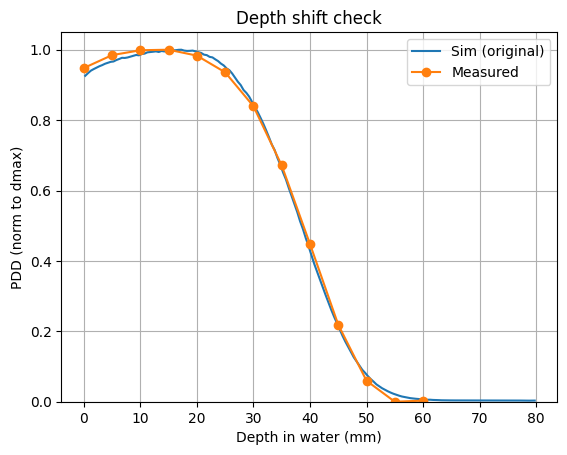

In [14]:
# =========================
# Depth-shift sensitivity test (mm)
# =========================
shifts = np.arange(-5.0, 5.0, 0.01)  # mm
rows = []

for s in shifts:
    sim_shift = np.interp(meas_depth_use, sim_depth + s, sim_pdd, left=np.nan, right=np.nan)
    m = np.isfinite(sim_shift)
    if not np.any(m):
        continue
    diff = sim_shift[m] - meas_pdd_use[m]
    mae  = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    rows.append((s, mae, rmse, np.max(np.abs(diff))))

shift_df = pd.DataFrame(rows, columns=["shift_mm","MAE","RMSE","MaxAbs"])
shift_df = shift_df.sort_values("MAE").reset_index(drop=True)
display(shift_df.head(10))

best = shift_df.iloc[0]
best_shift = float(best["shift_mm"])
print(f"Best shift = {best_shift:+.2f} mm (MAE={best['MAE']:.4f})")

# Plot overlay with best shift
sim_best = np.interp(meas_depth_use, sim_depth + best_shift, sim_pdd)
plt.figure()
plt.plot(sim_depth, sim_pdd, label="Sim (original)")
plt.plot(meas_depth, meas_pdd, "o-", label="Measured")
#plt.plot(meas_depth_use, sim_best, "s--", label=f"Sim shifted {best_shift:+.2f} mm")
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (norm to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.title("Depth shift check")
plt.show()

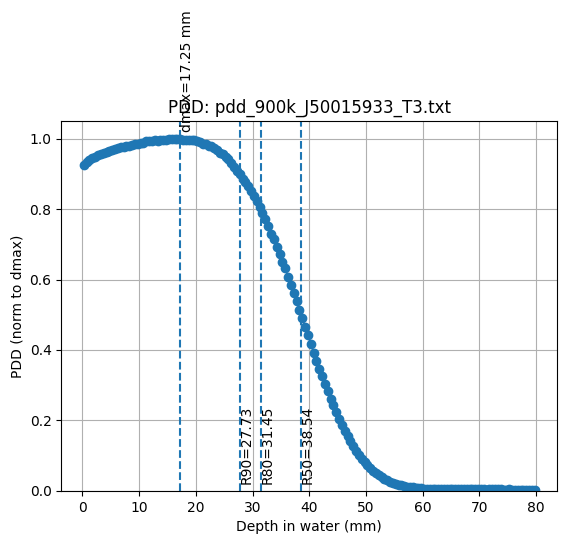

dz = 0.5
dmax = 17.25 mm
R90  = 27.72734028735507 mm
R80  = 31.44692515039502 mm
R50  = 38.53932230019592 mm


In [36]:
# ---- USER: point to your PDD file ----
PDD_TXT = Path("build") / "pdd_900k_J50015933_T3.txt"  # change
#build/pdd_r001_E9p85_sE1p00_sTh0p00_N300000_J50015985_T1.txt
NBIN_Z = 160
HALF_Z_MM = 40
DEPTH_MODE = "center"  # center is correct for voxel centers

df = read_geant4_mesh_dump(PDD_TXT)

# PDD mesh should be 1×1×NBIN_Z, so sum over iX,iY by iZ
g = df.groupby("iZ", as_index=False)["val"].sum()
all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

dose = g["val"].to_numpy()
if dose.max() <= 0:
    raise RuntimeError("Dose is zero everywhere - check mesh placement or beamOn.")

# Depth axis
full_len = 2*HALF_Z_MM
dz = full_len / NBIN_Z
if DEPTH_MODE == "center":
    depth_mm = (np.arange(NBIN_Z) + 0.5) * dz
else:
    depth_mm = np.arange(NBIN_Z) * dz

pdd = dose / dose.max()

def r_at_percent(depth_mm, pdd, percent):
    imax = int(np.argmax(pdd))
    d2 = depth_mm[imax:]
    y2 = pdd[imax:]
    if np.all(y2 >= percent):
        return np.nan
    j = np.where(y2 < percent)[0][0]
    if j == 0:
        return d2[0]
    dA, dB = d2[j-1], d2[j]
    yA, yB = y2[j-1], y2[j]
    return dA + (percent - yA) * (dB - dA) / (yB - yA)

dmax_idx = int(np.argmax(pdd))
dmax_mm  = float(depth_mm[dmax_idx])
R90 = r_at_percent(depth_mm, pdd, 0.90)
R80 = r_at_percent(depth_mm, pdd, 0.80)
R50 = r_at_percent(depth_mm, pdd, 0.50)

plt.figure()
plt.plot(depth_mm, pdd, marker="o", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (norm to dmax)")
plt.grid(True)
plt.ylim(0, 1.05)

plt.axvline(dmax_mm, linestyle="--")
plt.text(dmax_mm, 1.02, f"dmax={dmax_mm:.2f} mm", rotation=90, va="bottom")

for val, name in [(R90,"R90"), (R80,"R80"), (R50,"R50")]:
    if np.isfinite(val):
        plt.axvline(val, linestyle="--")
        plt.text(val, 0.02, f"{name}={val:.2f}", rotation=90, va="bottom")

plt.title(f"PDD: {PDD_TXT.name}")
plt.show()

print("dz =", dz)
print("dmax =", dmax_mm, "mm")
print("R90  =", R90, "mm")
print("R80  =", R80, "mm")
print("R50  =", R50, "mm")

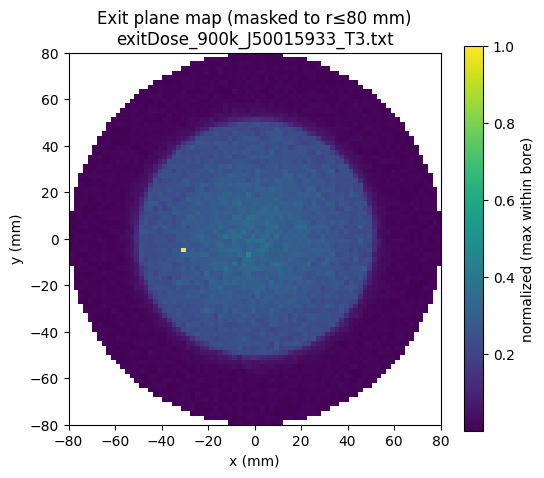

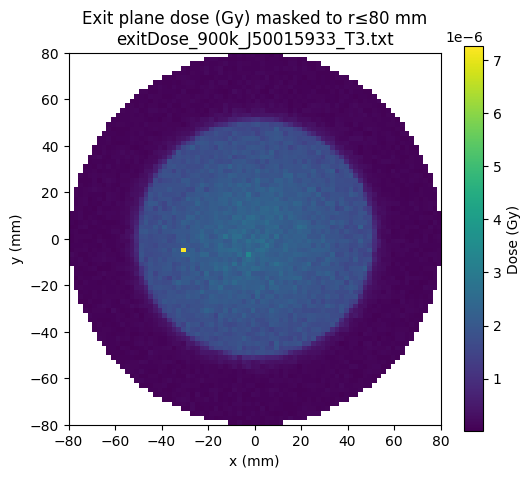

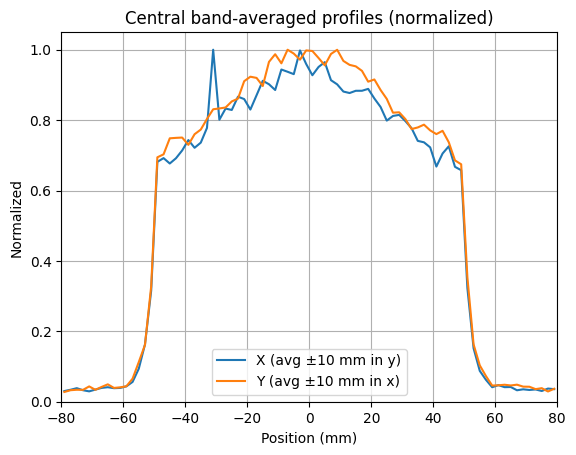

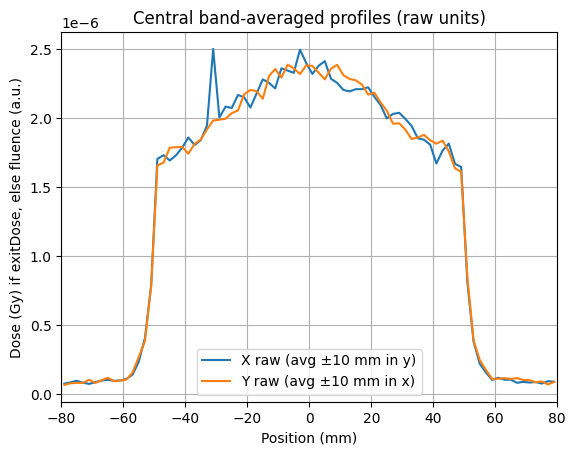

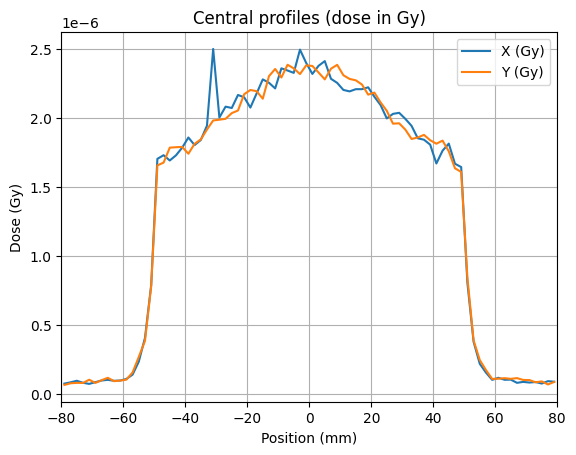

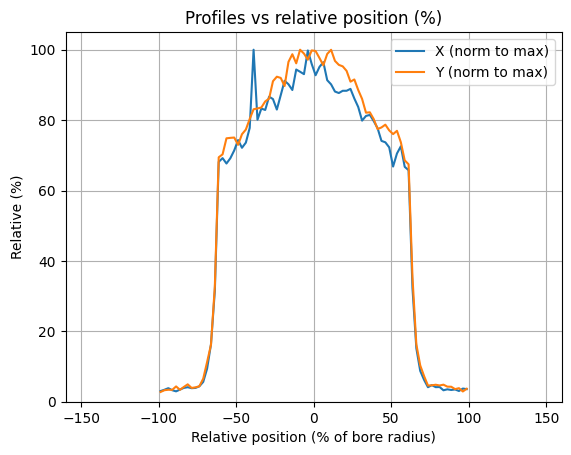

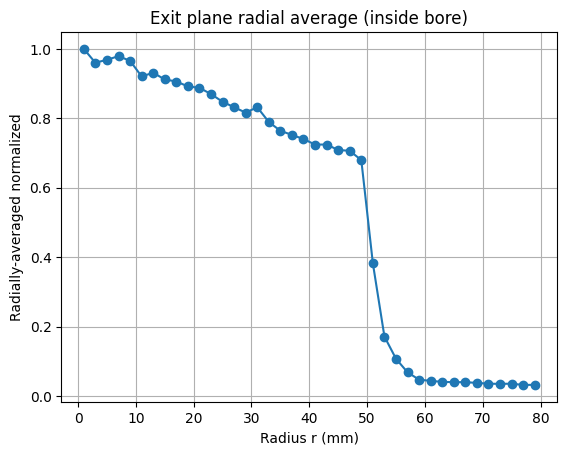

dx = 2.00 mm, dy = 2.00 mm
Using bore mask r <= 80.0 mm
Norm (max inside bore) = 7.26804e-06


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            try:
                ix, iy, iz = int(parts[0]), int(parts[1]), int(parts[2])
                val = float(parts[3])
                rows.append((ix, iy, iz, val))
            except ValueError:
                continue
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val"])

# =========================
# MUST MATCH YOUR MACRO
# /score/mesh/boxSize 80 80 0.25 mm
# /score/mesh/nBin    80 80 1
# =========================
TXT = Path("build") / "exitDose_900k_J50015933_T3.txt"  # change 
NX, NY = 80, 80
HALF_X_MM, HALF_Y_MM = 80.0, 80.0

# IMPORTANT: 10 cm applicator ID = 100 mm => radius 50 mm
boreR_mm = 80.0

# If this file is doseDeposit, set this True and we’ll also plot cGy
IS_DOSE_FILE = True   # True if you are reading exitDose (doseDeposit)

DOSE_UNIT = "Gy"   # "Gy", "cGy", "mGy", "uGy", "kGy"
SCALE = {"Gy":1.0, "cGy":100.0, "mGy":1e3, "uGy":1e6, "kGy":1e-3}[DOSE_UNIT]

# Read and reshape
df = read_geant4_mesh_dump(TXT)
df = df[df["iZ"] == 0].copy()

full = pd.MultiIndex.from_product([range(NX), range(NY)], names=["iX","iY"]).to_frame(index=False)
df = full.merge(df, on=["iX","iY"], how="left").fillna(0.0)
img = df.pivot(index="iY", columns="iX", values="val").to_numpy()

# Axes in mm
dx = 2*HALF_X_MM / NX
dy = 2*HALF_Y_MM / NY
x = (np.arange(NX) + 0.5)*dx - HALF_X_MM
y = (np.arange(NY) + 0.5)*dy - HALF_Y_MM

X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
inside = (R <= boreR_mm)

# Normalize to max INSIDE bore
norm = np.nanmax(np.where(inside, img, np.nan))
imgN = img / norm if norm > 0 else img

# Mask outside bore
imgN_masked = imgN.copy()
imgN_masked[~inside] = np.nan

# =========================
# 1) Heatmap (normalized)
# =========================
plt.figure(figsize=(6,5))
extent = [x[0]-dx/2, x[-1]+dx/2, y[0]-dy/2, y[-1]+dy/2]
plt.imshow(imgN_masked, origin="lower", extent=extent, aspect="equal")
plt.colorbar(label="normalized (max within bore)")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title(f"Exit plane map (masked to r≤{boreR_mm:.0f} mm)\n{TXT.name}")
plt.show()


if IS_DOSE_FILE:
    img_unit = img * SCALE
    img_unit_masked = img_unit.copy()
    img_unit_masked[~inside] = np.nan

    plt.figure(figsize=(6,5))
    plt.imshow(img_unit_masked, origin="lower", extent=extent, aspect="equal")
    plt.colorbar(label=f"Dose ({DOSE_UNIT})")
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.title(f"Exit plane dose ({DOSE_UNIT}) masked to r≤{boreR_mm:.0f} mm\n{TXT.name}")
    plt.show()
# =========================
# 2) Band-averaged central profiles (normalized)
# =========================
ix0, iy0 = NX//2, NY//2
band_mm = 10.0
band_px_y = max(1, int(round(band_mm / dy)))
band_px_x = max(1, int(round(band_mm / dx)))

x_band = imgN_masked[max(0, iy0-band_px_y):min(NY, iy0+band_px_y+1), :]
prof_xN = np.nanmean(x_band, axis=0)

y_band = imgN_masked[:, max(0, ix0-band_px_x):min(NX, ix0+band_px_x+1)]
prof_yN = np.nanmean(y_band, axis=1)

# renormalize each profile to its own max
px = prof_xN / np.nanmax(prof_xN) if np.nanmax(prof_xN) > 0 else prof_xN
py = prof_yN / np.nanmax(prof_yN) if np.nanmax(prof_yN) > 0 else prof_yN

plt.figure()
plt.plot(x, px, label=f"X (avg ±{band_mm:.0f} mm in y)")
plt.plot(y, py, label=f"Y (avg ±{band_mm:.0f} mm in x)")
plt.xlim(-HALF_X_MM, HALF_X_MM)
plt.ylim(0, 1.05)
plt.xlabel("Position (mm)")
plt.ylabel("Normalized")
plt.grid(True)
plt.legend()
plt.title("Central band-averaged profiles (normalized)")
plt.show()

# =========================
# 3) Central profiles in RAW units (Gy or a.u.)
# =========================
x_band_raw = img[max(0, iy0-band_px_y):min(NY, iy0+band_px_y+1), :]
prof_x_raw = np.nanmean(x_band_raw, axis=0)

y_band_raw = img[:, max(0, ix0-band_px_x):min(NX, ix0+band_px_x+1)]
prof_y_raw = np.nanmean(y_band_raw, axis=1)


plt.figure()
plt.plot(x, prof_x_raw, label=f"X raw (avg ±{band_mm:.0f} mm in y)")
plt.plot(y, prof_y_raw, label=f"Y raw (avg ±{band_mm:.0f} mm in x)")
plt.xlim(-HALF_X_MM, HALF_X_MM)
plt.xlabel("Position (mm)")
plt.ylabel("Dose (Gy) if exitDose, else fluence (a.u.)")
plt.grid(True)
plt.legend()
plt.title("Central band-averaged profiles (raw units)")
plt.show()

# Optional: if this is doseDeposit, also plot in cGy
if IS_DOSE_FILE:
    plt.figure()
    plt.plot(x, prof_x_raw * SCALE, label=f"X ({DOSE_UNIT})")
    plt.plot(y, prof_y_raw * SCALE, label=f"Y ({DOSE_UNIT})")
    plt.xlim(-HALF_X_MM, HALF_X_MM)
    plt.xlabel("Position (mm)")
    plt.ylabel(f"Dose ({DOSE_UNIT})")
    plt.grid(True)
    plt.legend()
    plt.title(f"Central profiles (dose in {DOSE_UNIT})")
    plt.show()

# =========================
# 4) Same profiles vs Relative position (%)
# =========================
x_rel = (x / boreR_mm) * 100.0   # -100..100 corresponds to -R..+R
y_rel = (y / boreR_mm) * 100.0

plt.figure()
plt.plot(x_rel, px*100.0, label="X (norm to max)")
plt.plot(y_rel, py*100.0, label="Y (norm to max)")
plt.xlim(-160, 160)  # show beyond field edge; change to (-120,120) if you prefer
plt.ylim(0, 105)
plt.xlabel("Relative position (% of bore radius)")
plt.ylabel("Relative (%)")
plt.grid(True)
plt.legend()
plt.title("Profiles vs relative position (%)")
plt.show()

# =========================
# 5) Radial average (robust + publishable)
# =========================
dr_mm = max(dx, dy)   # use pixel size
r_edges = np.arange(0, boreR_mm + dr_mm, dr_mm)
r_cent  = 0.5*(r_edges[:-1] + r_edges[1:])

rad = np.full_like(r_cent, np.nan, dtype=float)
for i in range(len(r_cent)):
    m = (R >= r_edges[i]) & (R < r_edges[i+1])
    rad[i] = np.nanmean(imgN_masked[m]) if np.any(m) else np.nan

radN = rad / np.nanmax(rad) if np.nanmax(rad) > 0 else rad

plt.figure()
plt.plot(r_cent, radN, marker="o")
plt.xlabel("Radius r (mm)")
plt.ylabel("Radially-averaged normalized")
plt.grid(True)
plt.title("Exit plane radial average (inside bore)")
plt.show()

print(f"dx = {dx:.2f} mm, dy = {dy:.2f} mm")
print(f"Using bore mask r <= {boreR_mm:.1f} mm")
print(f"Norm (max inside bore) = {norm:.6g}")

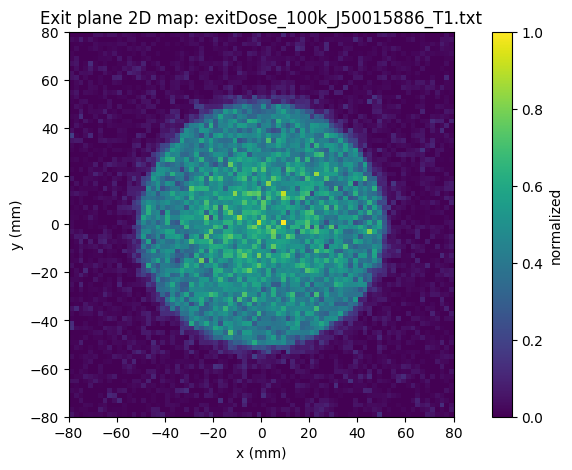

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            ix, iy, iz = int(parts[0]), int(parts[1]), int(parts[2])
            val = float(parts[3])
            rows.append((ix, iy, iz, val))
    return pd.DataFrame(rows, columns=["iX","iY","iZ","val"])

# ---- USER ----
TXT = Path("build") / "exitDose_100k_J50015886_T1.txt"   # or exit2D_dose.txt
#build/exitFluence_500k_J50015714_T1.txt
NX, NY = 80, 80
HALF_X_MM, HALF_Y_MM = 80.0, 80.0

df = read_geant4_mesh_dump(TXT)
df = df[df["iZ"] == 0].copy()

# fill missing pixels with 0
full = pd.MultiIndex.from_product([range(NX), range(NY)], names=["iX","iY"]).to_frame(index=False)
df = full.merge(df, on=["iX","iY"], how="left").fillna(0.0)

img = df.pivot(index="iY", columns="iX", values="val").to_numpy()

# axes in mm
dx = 2*HALF_X_MM / NX  # 100/200 = 0.5 mm
dy = 2*HALF_Y_MM / NY  # 100/200 = 0.5 mm
x = (np.arange(NX) + 0.5)*dx - HALF_X_MM
y = (np.arange(NY) + 0.5)*dy - HALF_Y_MM

# normalize for display (film-like)
m = img.max()
imgN = img/m if m > 0 else img

plt.figure(figsize=(10,5))
extent = [x[0]-dx/2, x[-1]+dx/2, y[0]-dy/2, y[-1]+dy/2]
plt.imshow(imgN, origin="lower", extent=extent, aspect="equal")
plt.colorbar(label="normalized")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title(f"Exit plane 2D map: {TXT.name}")
plt.show()

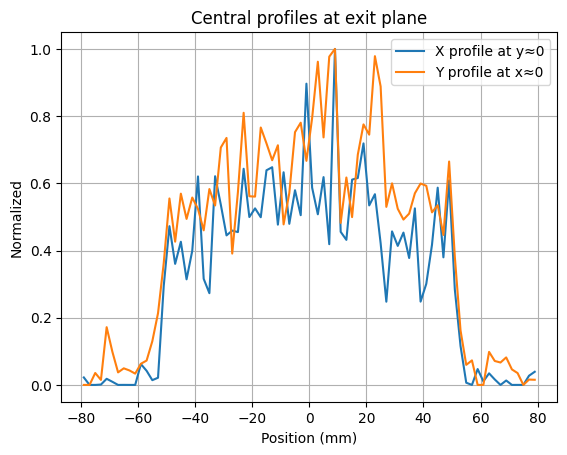

In [22]:
ix0 = NX // 2
iy0 = NY // 2

prof_x = imgN[iy0, :]
prof_y = imgN[:, ix0]

px = prof_x / prof_x.max() if prof_x.max() > 0 else prof_x
py = prof_y / prof_y.max() if prof_y.max() > 0 else prof_y

plt.figure()
plt.plot(x, px, label="X profile at y≈0")
plt.plot(y, py, label="Y profile at x≈0")
plt.xlabel("Position (mm)")
plt.ylabel("Normalized")
plt.grid(True)
plt.legend()
plt.title("Central profiles at exit plane")
plt.show()

px=prof_x/prof.x.ma

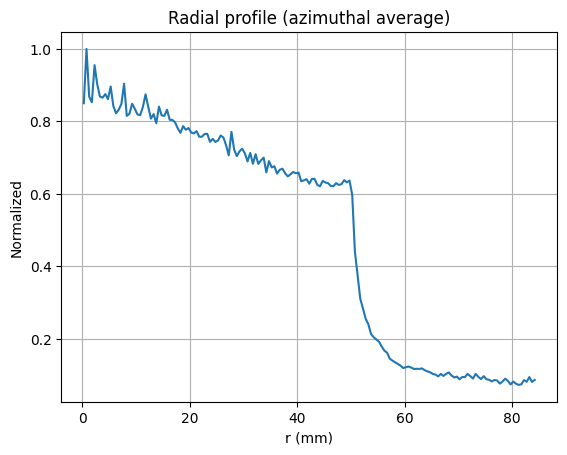

In [20]:
XX, YY = np.meshgrid(x, y)
R = np.sqrt(XX**2 + YY**2)

vals = img.flatten()
rr = R.flatten()

# radial binning
dr = 0.5  # mm
rbins = np.arange(0, rr.max()+dr, dr)
rcent = 0.5*(rbins[:-1] + rbins[1:])

rad = np.zeros_like(rcent)
counts = np.zeros_like(rcent)

inds = np.digitize(rr, rbins) - 1
mask = (inds >= 0) & (inds < len(rcent))

for i, v in zip(inds[mask], vals[mask]):
    rad[i] += v
    counts[i] += 1

rad = np.divide(rad, counts, out=np.zeros_like(rad), where=counts>0)
radN = rad / rad.max() if rad.max() > 0 else rad

plt.figure()
plt.plot(rcent, radN)
plt.xlabel("r (mm)")
plt.ylabel("Normalized")
plt.grid(True)
plt.title("Radial profile (azimuthal average)")
plt.show()

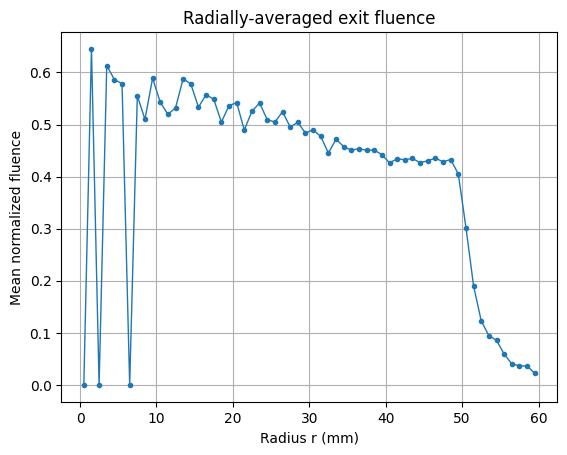

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Uses x, y, img from the previous cell
X, Y = np.meshgrid(x, y)              # shape (NY, NX)
R = np.sqrt(X**2 + Y**2)

rmax = 60.0
dr = 1.0                               # 1 mm radial bins
rbins = np.arange(0, rmax+dr, dr)

imgN = img / img.max() if img.max() > 0 else img

radial = np.zeros(len(rbins)-1)
counts = np.zeros(len(rbins)-1)

rflat = R.ravel()
vflat = imgN.ravel()

inds = np.digitize(rflat, rbins) - 1
valid = (inds >= 0) & (inds < len(radial))

for i, v in zip(inds[valid], vflat[valid]):
    radial[i] += v
    counts[i] += 1

radial = np.divide(radial, counts, out=np.zeros_like(radial), where=counts>0)
rcent = 0.5*(rbins[:-1] + rbins[1:])

plt.figure()
plt.plot(rcent, radial, "-o", linewidth=1, markersize=3)
plt.xlabel("Radius r (mm)")
plt.ylabel("Mean normalized fluence")
plt.grid(True)
plt.title("Radially-averaged exit fluence")
plt.show()

In [ ]:
xxxxx

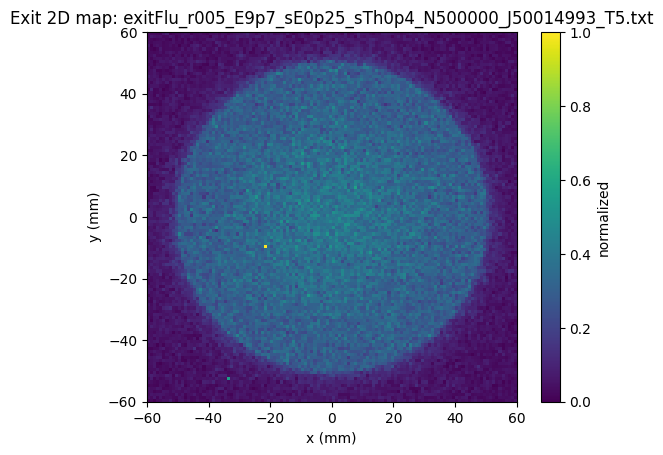

In [7]:
# ---- USER: point to your 2D file ----
EXIT2D_TXT = Path("build") / "exitFlu_r005_E9p7_sE0p25_sTh0p4_N500000_J50014993_T5.txt"  # change
# build/exitFlu_r005_E9p7_sE0p25_sTh0p4_N500000_J50014993_T5.txt

NX, NY = 120, 120
HALF_X_MM, HALF_Y_MM = 60.0, 60.0   # match macro /score/mesh/boxSize

df = read_geant4_mesh_dump(EXIT2D_TXT)
df = df[df["iZ"] == 0].copy()

# fill missing voxels with 0
full = pd.MultiIndex.from_product([range(NX), range(NY)], names=["iX","iY"]).to_frame(index=False)
df = full.merge(df, on=["iX","iY"], how="left").fillna(0.0)

img = df.pivot(index="iY", columns="iX", values="val").to_numpy()

dx = 2*HALF_X_MM / NX
dy = 2*HALF_Y_MM / NY
x = (np.arange(NX) + 0.5)*dx - HALF_X_MM
y = (np.arange(NY) + 0.5)*dy - HALF_Y_MM

# Normalize for film-like appearance
m = img.max()
imgN = img/m if m > 0 else img

plt.figure()
extent = [x[0]-dx/2, x[-1]+dx/2, y[0]-dy/2, y[-1]+dy/2]
plt.imshow(imgN, origin="lower", extent=extent, aspect="equal")
plt.colorbar(label="normalized")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title(f"Exit 2D map: {EXIT2D_TXT.name}")
plt.show()

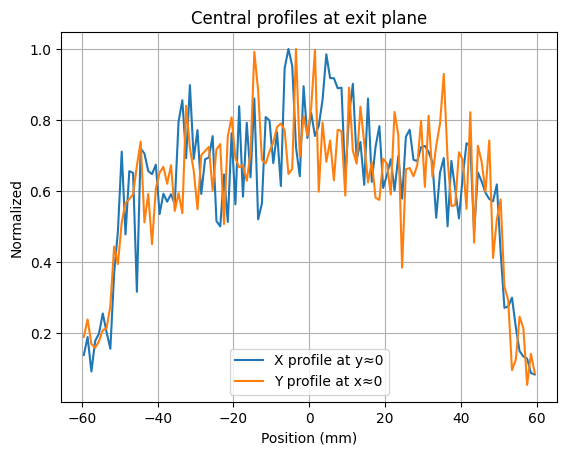

In [8]:
ix0 = NX//2
iy0 = NY//2

prof_x = img[iy0, :]
prof_y = img[:, ix0]

px = prof_x / prof_x.max() if prof_x.max() > 0 else prof_x
py = prof_y / prof_y.max() if prof_y.max() > 0 else prof_y

plt.figure()
plt.plot(x, px, label="X profile at y≈0")
plt.plot(y, py, label="Y profile at x≈0")
plt.xlabel("Position (mm)")
plt.ylabel("Normalized")
plt.grid(True)
plt.legend()
plt.title("Central profiles at exit plane")
plt.show()

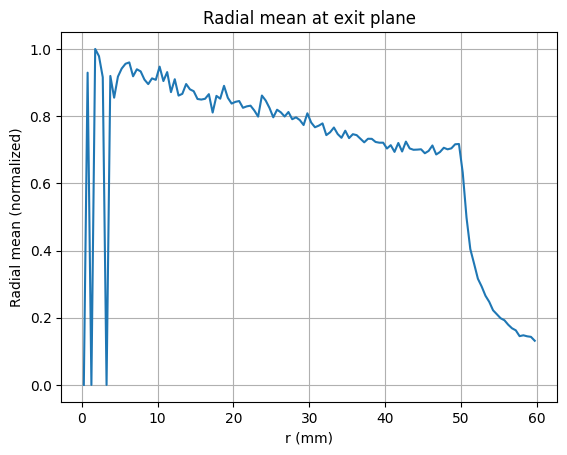

In [9]:
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)

rmax = 60.0
dr = 0.5
rbins = np.arange(0, rmax+dr, dr)

rad = np.zeros(len(rbins)-1)
cnt = np.zeros(len(rbins)-1)

flatR = R.ravel()
flatV = img.ravel()

for i in range(len(rbins)-1):
    msk = (flatR >= rbins[i]) & (flatR < rbins[i+1])
    if np.any(msk):
        rad[i] = np.mean(flatV[msk])
        cnt[i] = np.sum(msk)

rcent = 0.5*(rbins[:-1]+rbins[1:])
radN = rad / np.max(rad) if np.max(rad) > 0 else rad

plt.figure()
plt.plot(rcent, radN)
plt.xlabel("r (mm)")
plt.ylabel("Radial mean (normalized)")
plt.grid(True)
plt.title("Radial mean at exit plane")
plt.show()

In [24]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# USER SETTINGS
# =========================
NBIN_Z = 1
HALF_Z_MM = 0.5        # mesh half-length in Z (mm) -> full length = 80 mm
DEPTH_MODE = "center"   # "center" or "edge"

# Paths (relative to your project root where the notebook sits)
INPUT_TXT = Path("build") / "pdd_100k_A50014566_T1.txt"
# build/pdd_100k_A50014566_T1.txt

# Output in same folder as input (build/)
OUT_DIR = INPUT_TXT.parent
OUT_CSV = OUT_DIR / "pdd_processed.csv"
OUT_PNG = OUT_DIR / "pdd_plot.png"



def read_geant4_mesh_dump(path: Path) -> pd.DataFrame:
    """
    Reads Geant4 /score/dumpQuantityToFile output:
    lines like: iX,iY,iZ,total(value),total(val^2),entry
    Returns a DataFrame with numeric columns.
    """
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = [p.strip() for p in line.split(",")]
            if len(parts) < 6:
                continue
            try:
                ix = int(parts[0]); iy = int(parts[1]); iz = int(parts[2])
                val = float(parts[3])
                val2 = float(parts[4])
                entry = int(float(parts[5]))
                rows.append((ix, iy, iz, val, val2, entry))
            except ValueError:
                continue

    return pd.DataFrame(rows, columns=["iX", "iY", "iZ", "dose_Gy", "dose2", "entry"])


def compute_depth_axis(nbin_z: int, half_z_mm: float, mode: str = "center"):
    full_len = 2.0 * half_z_mm
    dz = full_len / nbin_z
    if mode == "center":
        z = (np.arange(nbin_z) + 0.5) * dz
    elif mode == "edge":
        z = np.arange(nbin_z) * dz
    else:
        raise ValueError("DEPTH_MODE must be 'center' or 'edge'")
    return z, dz


def r_at_percent(depth_mm, pdd, percent):
    """Depth where PDD falls to `percent` on distal side of dmax (linear interp)."""
    imax = int(np.argmax(pdd))
    d2 = depth_mm[imax:]
    y2 = pdd[imax:]

    if np.all(y2 >= percent):
        return np.nan

    j = np.where(y2 < percent)[0][0]
    if j == 0:
        return d2[0]

    dA, dB = d2[j - 1], d2[j]
    yA, yB = y2[j - 1], y2[j]
    return dA + (percent - yA) * (dB - dA) / (yB - yA)


# =========
# MAIN RUN
# =========
print("Working directory:", Path.cwd())
print("Input file:", INPUT_TXT.resolve())

if not INPUT_TXT.exists():
    raise FileNotFoundError(f"File not found:\n{INPUT_TXT.resolve()}")

# Confirm updated time
mtime = INPUT_TXT.stat().st_mtime
print("Last modified:", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime(mtime)))

df = read_geant4_mesh_dump(INPUT_TXT)

g = df.groupby("iZ", as_index=False)["dose_Gy"].sum()
all_iz = pd.DataFrame({"iZ": np.arange(NBIN_Z)})
g = all_iz.merge(g, on="iZ", how="left").fillna(0.0)

depth_mm, dz = compute_depth_axis(NBIN_Z, HALF_Z_MM, mode=DEPTH_MODE)


dose = g["dose_Gy"].to_numpy()
if dose.max() <= 0:
    raise RuntimeError("All dose values are zero. Check beamOn, geometry alignment, and scoring volume location.")

pdd = dose / dose.max()
dmax_index = int(np.argmax(pdd))
dmax_mm = float(depth_mm[dmax_index])

r90_mm = r_at_percent(depth_mm, pdd, 0.90)
r80_mm = r_at_percent(depth_mm, pdd, 0.80)
r50_mm = r_at_percent(depth_mm, pdd, 0.50)

out = pd.DataFrame({"depth_mm": depth_mm, "dose_Gy": dose, "pdd_norm": pdd})
out.to_csv(OUT_CSV, index=False)

plt.figure()
plt.plot(depth_mm, pdd, marker="o", linewidth=1)
plt.xlabel("Depth in water (mm)")
plt.ylabel("PDD (normalized to dmax)")
plt.ylim(0, 1.05)
plt.grid(True)

plt.axvline(dmax_mm, linestyle="--", linewidth=1)
plt.text(dmax_mm, 1.02, f"dmax={dmax_mm:.2f} mm", rotation=90, va="bottom")

for val, name in [(r90_mm, "R90"), (r80_mm, "R80"), (r50_mm, "R50")]:
    if np.isfinite(val):
        plt.axvline(val, linestyle="--", linewidth=1)
        plt.text(val, 0.02, f"{name}={val:.2f} mm", rotation=90, va="bottom")

plt.title("PDD from Geant4 mesh dump")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=200)
plt.show()

print("\n================= PDD SUMMARY =================")
print(f"dz (mm) = {dz:.3f}  (HALF_Z_MM={HALF_Z_MM}, NBIN_Z={NBIN_Z}, DEPTH_MODE={DEPTH_MODE})")
print(f"dmax  = {dmax_mm:.2f} mm  (iZ={dmax_index})")
print(f"R90   = {r90_mm:.2f} mm")
print(f"R80   = {r80_mm:.2f} mm")
print(f"R50   = {r50_mm:.2f} mm")
print(f"Saved: {OUT_CSV.resolve()}")
print(f"Saved: {OUT_PNG.resolve()}")
print("==============================================")


Working directory: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim
Input file: /rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_100k_A50014566_T1.txt


FileNotFoundError: File not found:
/rhea/scratch/brussel/113/vsc11383/projects/third_sim/FlashElectronSim/build/pdd_100k_A50014566_T1.txt